## EWMA: 監控每日下午時段的 hourly PM2.5 是否持續偏高

The standardized hourly PM2.5 value is defined as:

$$
Z_i = \frac{X_i - \mu_h}{\sigma_h}
$$

where $X_i$ is the observed PM2.5 concentration at time $i$, and $\mu_h$ and $\sigma_h$ are the Phase I mean and standard deviation for hour $h$.

The EWMA statistic is calculated as:

$$
E_i = \lambda Z_i + (1-\lambda)E_{i-1}
$$

with

$$
E_0 = 0.
$$

Since the standardized PM2.5 values have a center line of 0, the EWMA center line is defined as:

$$
CL = 0.
$$

The upper and lower control limits at time $i$ are defined as:

$$
UCL_i = L \sqrt{\frac{\lambda}{2-\lambda}
\left[1-(1-\lambda)^{2i}\right]}
$$

$$
LCL_i = -L \sqrt{\frac{\lambda}{2-\lambda}
\left[1-(1-\lambda)^{2i}\right]}.
$$

An upper out-of-control signal is detected when:

$$
E_i > UCL_i.
$$

In this study, $\lambda=0.15$ and $L=3$ were used. The EWMA chart was applied to monitor sustained upward deviations in standardized PM2.5 levels during the afternoon period.

## Phase1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
def make_period_hourly_phase_data(file, start_hour=12, end_hour=17):
    df = pd.read_excel(file)

    df["monitordate"] = pd.to_datetime(df["monitordate"])
    df = df.sort_values("monitordate").reset_index(drop=True)

    df["date"] = df["monitordate"].dt.date
    df["hour"] = df["monitordate"].dt.hour
    df["day"] = df["monitordate"].dt.day

    df_period = df[
        (df["hour"] >= start_hour) &
        (df["hour"] <= end_hour)
    ].copy()

    hourly_data = df_period[[
        "monitordate",
        "date",
        "day",
        "hour",
        "PM2.5"
    ]].copy()

    hourly_data = hourly_data.rename(columns={
        "PM2.5": "pm25"
    })

    print(f"\nHourly PM2.5 data for {file}:")
    print(hourly_data.head())

    print("\nData size:")
    print(hourly_data.shape)

    print("\nHour distribution:")
    print(hourly_data["hour"].value_counts().sort_index())

    print("\nMissing PM2.5 count:")
    print(hourly_data["pm25"].isna().sum())

    return hourly_data


phase1_hourly_data = make_period_hourly_phase_data(
    "air_quality_202501.xlsx",
    start_hour=12,
    end_hour=17
)

phase2_hourly_data = make_period_hourly_phase_data(
    "air_quality_202601.xlsx",
    start_hour=12,
    end_hour=17
)


Hourly PM2.5 data for air_quality_202501.xlsx:
           monitordate        date  day  hour  pm25
12 2025-01-01 12:00:00  2025-01-01    1    12   9.0
13 2025-01-01 13:00:00  2025-01-01    1    13  11.0
14 2025-01-01 14:00:00  2025-01-01    1    14  11.0
15 2025-01-01 15:00:00  2025-01-01    1    15  18.0
16 2025-01-01 16:00:00  2025-01-01    1    16  11.0

Data size:
(186, 5)

Hour distribution:
hour
12    31
13    31
14    31
15    31
16    31
17    31
Name: count, dtype: int64

Missing PM2.5 count:
2

Hourly PM2.5 data for air_quality_202601.xlsx:
           monitordate        date  day  hour  pm25
12 2026-01-01 12:00:00  2026-01-01    1    12   4.0
13 2026-01-01 13:00:00  2026-01-01    1    13   7.0
14 2026-01-01 14:00:00  2026-01-01    1    14   8.0
15 2026-01-01 15:00:00  2026-01-01    1    15   8.0
16 2026-01-01 16:00:00  2026-01-01    1    16   7.0

Data size:
(186, 5)

Hour distribution:
hour
12    31
13    31
14    31
15    31
16    31
17    31
Name: count, dtype: int64

Mis

In [3]:
phase1_hourly_baseline = phase1_hourly_data.groupby("hour").agg(
    mean_pm25=("pm25", "mean"),
    sd_pm25=("pm25", "std"),
    n=("pm25", "count")
).reset_index()

phase1_hourly_baseline["sd_pm25"] = phase1_hourly_baseline["sd_pm25"].replace(0, np.nan)

print("\nPhase I hourly baseline:")
print(phase1_hourly_baseline)


Phase I hourly baseline:
   hour  mean_pm25   sd_pm25   n
0    12   9.774194  5.613731  31
1    13  11.322581  7.871413  31
2    14  12.833333  9.699212  30
3    15  12.612903  8.807865  31
4    16  12.800000  7.923775  30
5    17  13.193548  8.506544  31


In [4]:
def ewma_limits(hourly_data, baseline, lam=0.2, L=3):
    stats = hourly_data.copy()

    stats = stats.merge(
        baseline[["hour", "mean_pm25", "sd_pm25"]],
        on="hour",
        how="left"
    )

    stats["z"] = (stats["pm25"] - stats["mean_pm25"]) / stats["sd_pm25"]

    stats["ewma"] = 0.0
    stats["valid_order"] = 0

    previous_ewma = 0
    valid_count = 0

    for i in range(len(stats)):
        z = stats.loc[i, "z"]

        if pd.isna(z):
            stats.loc[i, "ewma"] = previous_ewma
            stats.loc[i, "valid_order"] = valid_count
        else:
            valid_count += 1
            current_ewma = lam * z + (1 - lam) * previous_ewma

            stats.loc[i, "ewma"] = current_ewma
            stats.loc[i, "valid_order"] = valid_count

            previous_ewma = current_ewma

    stats["cl"] = 0

    stats["ewma_sd"] = np.sqrt(
        (lam / (2 - lam)) *
        (1 - (1 - lam) ** (2 * stats["valid_order"]))
    )

    stats["ucl"] = L * stats["ewma_sd"]
    stats["lcl"] = -L * stats["ewma_sd"]

    stats.loc[stats["valid_order"] == 0, ["ucl", "lcl"]] = np.nan

    stats["out_of_control_high"] = stats["ewma"] > stats["ucl"]
    stats["out_of_control_low"] = stats["ewma"] < stats["lcl"]

    stats["out_of_control_ewma"] = (
        stats["out_of_control_high"] |
        stats["out_of_control_low"]
    )

    return stats

In [5]:
phase1_ewma_stats = ewma_limits(
    phase1_hourly_data,
    phase1_hourly_baseline,
    lam=0.15,
    L=3
)

phase1_ewma_stats = phase1_ewma_stats.reset_index(drop=True)

print("EWMA out-of-control points:")
print(
    phase1_ewma_stats.loc[
        phase1_ewma_stats["out_of_control_ewma"],
        [
            "monitordate",
            "hour",
            "pm25",
            "z",
            "ewma",
            "ucl",
            "lcl"
        ]
    ]
)

EWMA out-of-control points:
            monitordate  hour  pm25         z      ewma       ucl       lcl
85  2025-01-15 13:00:00    13  35.0  3.008027  1.039359  0.854242 -0.854242
86  2025-01-15 14:00:00    14  33.0  2.079207  1.195336  0.854242 -0.854242
87  2025-01-15 15:00:00    15  27.0  1.633437  1.261051  0.854242 -0.854242
88  2025-01-15 16:00:00    16  25.0  1.539670  1.302844  0.854242 -0.854242
89  2025-01-15 17:00:00    17  25.0  1.387926  1.315607  0.854242 -0.854242
90  2025-01-16 12:00:00    12   5.0 -0.850449  0.990698  0.854242 -0.854242
127 2025-01-22 13:00:00    13  36.0  3.135069  1.166831  0.854242 -0.854242
128 2025-01-22 14:00:00    14  50.0  3.831926  1.566595  0.854242 -0.854242
129 2025-01-22 15:00:00    15  44.0  3.563530  1.866136  0.854242 -0.854242
130 2025-01-22 16:00:00    16  41.0  3.558910  2.120052  0.854242 -0.854242
131 2025-01-22 17:00:00    17  47.0  3.974170  2.398170  0.854242 -0.854242
132 2025-01-23 12:00:00    12  11.0  0.218359  2.071198  0.8

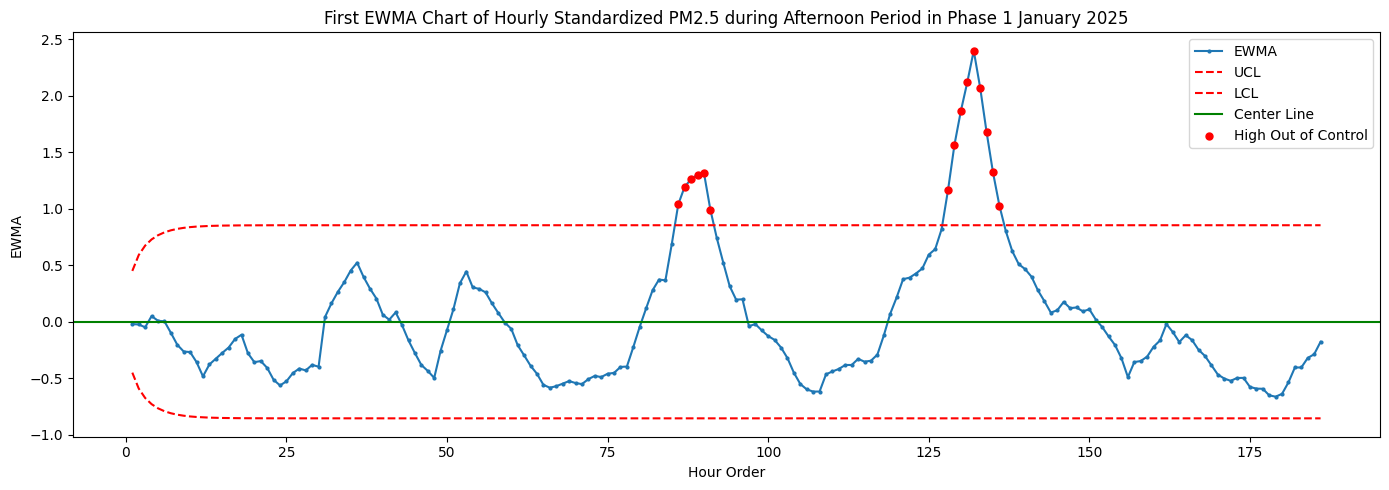

In [6]:
plt.figure(figsize=(14, 5))

x = np.arange(1, len(phase1_ewma_stats) + 1)

plt.plot(
    x,
    phase1_ewma_stats["ewma"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="EWMA"
)

plt.plot(
    x,
    phase1_ewma_stats["ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_ewma_stats["lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="-",
    label="Center Line"
)

out_high = phase1_ewma_stats["out_of_control_high"]
out_low = phase1_ewma_stats["out_of_control_low"]

plt.scatter(
    x[out_high],
    phase1_ewma_stats.loc[out_high, "ewma"],
    color="red",
    s=25,
    zorder=5,
    label="High Out of Control"
)


plt.title("First EWMA Chart of Hourly Standardized PM2.5 during Afternoon Period in Phase 1 January 2025")
plt.xlabel("Hour Order")
plt.ylabel("EWMA")
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
# Remove high out-of-control points detected in the first Phase I EWMA chart
phase1_high_out_points = phase1_ewma_stats.loc[
    phase1_ewma_stats["out_of_control_high"],
    "monitordate"
]

phase1_hourly_data_clean = phase1_hourly_data[
    ~phase1_hourly_data["monitordate"].isin(phase1_high_out_points)
].copy()

phase1_hourly_data_clean = phase1_hourly_data_clean.reset_index(drop=True)

print("Original Phase I size:", phase1_hourly_data.shape)
print("Cleaned Phase I size:", phase1_hourly_data_clean.shape)

Original Phase I size: (186, 5)
Cleaned Phase I size: (171, 5)


In [8]:
phase1_hourly_baseline_clean = phase1_hourly_data_clean.groupby("hour").agg(
    mean_pm25=("pm25", "mean"),
    sd_pm25=("pm25", "std"),
    n=("pm25", "count")
).reset_index()

phase1_hourly_baseline_clean["sd_pm25"] = (
    phase1_hourly_baseline_clean["sd_pm25"].replace(0, np.nan)
)

print("\nCleaned Phase I hourly baseline:")
print(phase1_hourly_baseline_clean)


Cleaned Phase I hourly baseline:
   hour  mean_pm25   sd_pm25   n
0    12   9.896552  5.734263  29
1    13   9.750000  4.718953  28
2    14  10.962963  5.543406  27
3    15  11.178571  6.224525  28
4    16  11.357143  5.505649  28
5    17  11.620690  5.401149  29


In [9]:
phase1_ewma_stats_clean = ewma_limits(
    phase1_hourly_data_clean,
    phase1_hourly_baseline_clean,
    lam=0.15,
    L=3
)

phase1_ewma_stats_clean = phase1_ewma_stats_clean.reset_index(drop=True)

print("EWMA out-of-control points after cleaning:")
print(
    phase1_ewma_stats_clean.loc[
        phase1_ewma_stats_clean["out_of_control_ewma"],
        [
            "monitordate",
            "hour",
            "pm25",
            "z",
            "ewma",
            "ucl",
            "lcl"
        ]
    ]
)

EWMA out-of-control points after cleaning:
            monitordate  hour  pm25         z      ewma       ucl       lcl
35  2025-01-06 17:00:00    17  21.0  1.736540  0.980663  0.854239 -0.854239
52  2025-01-09 16:00:00    16  21.0  1.751448  0.884331  0.854242 -0.854242
84  2025-01-15 12:00:00    12  24.0  2.459505  1.049743  0.854242 -0.854242
117 2025-01-21 15:00:00    15  19.0  1.256550  0.905311  0.854242 -0.854242
118 2025-01-21 16:00:00    16  23.0  2.114711  1.086721  0.854242 -0.854242
119 2025-01-21 17:00:00    17  21.0  1.736540  1.184194  0.854242 -0.854242
120 2025-01-22 12:00:00    12  20.0  1.761944  1.270856  0.854242 -0.854242
121 2025-01-23 16:00:00    16   9.0 -0.428132  1.016008  0.854242 -0.854242


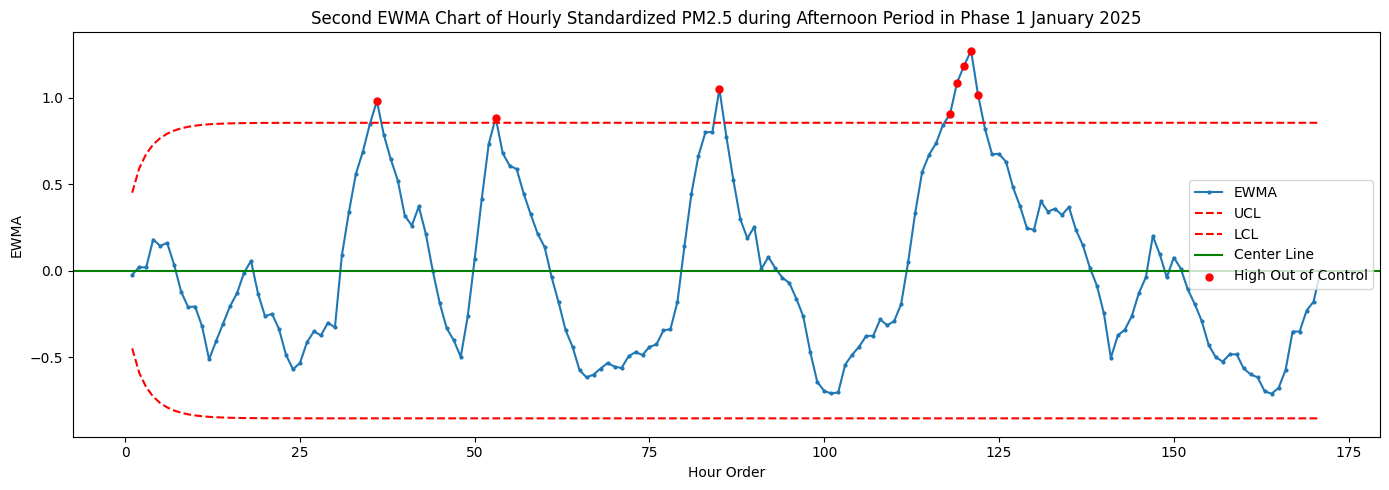

In [10]:
plt.figure(figsize=(14, 5))

x = np.arange(1, len(phase1_ewma_stats_clean) + 1)

plt.plot(
    x,
    phase1_ewma_stats_clean["ewma"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="EWMA"
)

plt.plot(
    x,
    phase1_ewma_stats_clean["ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_ewma_stats_clean["lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="-",
    label="Center Line"
)

out_high = phase1_ewma_stats_clean["out_of_control_high"]
out_low = phase1_ewma_stats_clean["out_of_control_low"]

plt.scatter(
    x[out_high],
    phase1_ewma_stats_clean.loc[out_high, "ewma"],
    color="red",
    s=25,
    zorder=5,
    label="High Out of Control"
)


plt.title("Second EWMA Chart of Hourly Standardized PM2.5 during Afternoon Period in Phase 1 January 2025")
plt.xlabel("Hour Order")
plt.ylabel("EWMA")
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# Second cleaning: remove high out-of-control points from the cleaned Phase I data
phase1_high_out_points_second = phase1_ewma_stats_clean.loc[
    phase1_ewma_stats_clean["out_of_control_high"],
    "monitordate"
]

print("Second round removed high out-of-control points:")
print(
    phase1_ewma_stats_clean.loc[
        phase1_ewma_stats_clean["out_of_control_high"],
        [
            "monitordate",
            "hour",
            "pm25",
            "z",
            "ewma",
            "ucl"
        ]
    ]
)

phase1_hourly_data_clean2 = phase1_hourly_data_clean[
    ~phase1_hourly_data_clean["monitordate"].isin(phase1_high_out_points_second)
].copy()

phase1_hourly_data_clean2 = phase1_hourly_data_clean2.reset_index(drop=True)

print("Previous cleaned Phase I size:", phase1_hourly_data_clean.shape)
print("Second cleaned Phase I size:", phase1_hourly_data_clean2.shape)

Second round removed high out-of-control points:
            monitordate  hour  pm25         z      ewma       ucl
35  2025-01-06 17:00:00    17  21.0  1.736540  0.980663  0.854239
52  2025-01-09 16:00:00    16  21.0  1.751448  0.884331  0.854242
84  2025-01-15 12:00:00    12  24.0  2.459505  1.049743  0.854242
117 2025-01-21 15:00:00    15  19.0  1.256550  0.905311  0.854242
118 2025-01-21 16:00:00    16  23.0  2.114711  1.086721  0.854242
119 2025-01-21 17:00:00    17  21.0  1.736540  1.184194  0.854242
120 2025-01-22 12:00:00    12  20.0  1.761944  1.270856  0.854242
121 2025-01-23 16:00:00    16   9.0 -0.428132  1.016008  0.854242
Previous cleaned Phase I size: (171, 5)
Second cleaned Phase I size: (163, 5)


In [12]:
phase1_hourly_baseline_clean2 = phase1_hourly_data_clean2.groupby("hour").agg(
    mean_pm25=("pm25", "mean"),
    sd_pm25=("pm25", "std"),
    n=("pm25", "count")
).reset_index()

phase1_hourly_baseline_clean2["sd_pm25"] = (
    phase1_hourly_baseline_clean2["sd_pm25"].replace(0, np.nan)
)

print("\nSecond cleaned Phase I hourly baseline:")
print(phase1_hourly_baseline_clean2)


Second cleaned Phase I hourly baseline:
   hour  mean_pm25   sd_pm25   n
0    12   9.000000  4.795832  27
1    13   9.750000  4.718953  28
2    14  10.962963  5.543406  27
3    15  10.888889  6.147753  27
4    16  10.600000  4.873397  25
5    17  10.925926  4.914077  27


In [13]:
phase1_ewma_stats_clean2 = ewma_limits(
    phase1_hourly_data_clean2,
    phase1_hourly_baseline_clean2,
    lam=0.15,
    L=3
)

phase1_ewma_stats_clean2 = phase1_ewma_stats_clean2.reset_index(drop=True)

print("EWMA out-of-control points after second cleaning:")
print(
    phase1_ewma_stats_clean2.loc[
        phase1_ewma_stats_clean2["out_of_control_ewma"],
        [
            "monitordate",
            "hour",
            "pm25",
            "z",
            "ewma",
            "ucl",
            "lcl"
        ]
    ]
)

EWMA out-of-control points after second cleaning:
            monitordate  hour  pm25         z      ewma       ucl       lcl
34  2025-01-06 16:00:00    16  21.0  2.134035  0.993131  0.854237 -0.854237
80  2025-01-14 16:00:00    16  20.0  1.928839  0.918273  0.854242 -0.854242
81  2025-01-14 17:00:00    17  16.0  1.032559  0.935416  0.854242 -0.854242
112 2025-01-21 13:00:00    13  15.0  1.112535  0.891599  0.854242 -0.854242
113 2025-01-21 14:00:00    14  19.0  1.449837  0.975335  0.854242 -0.854242


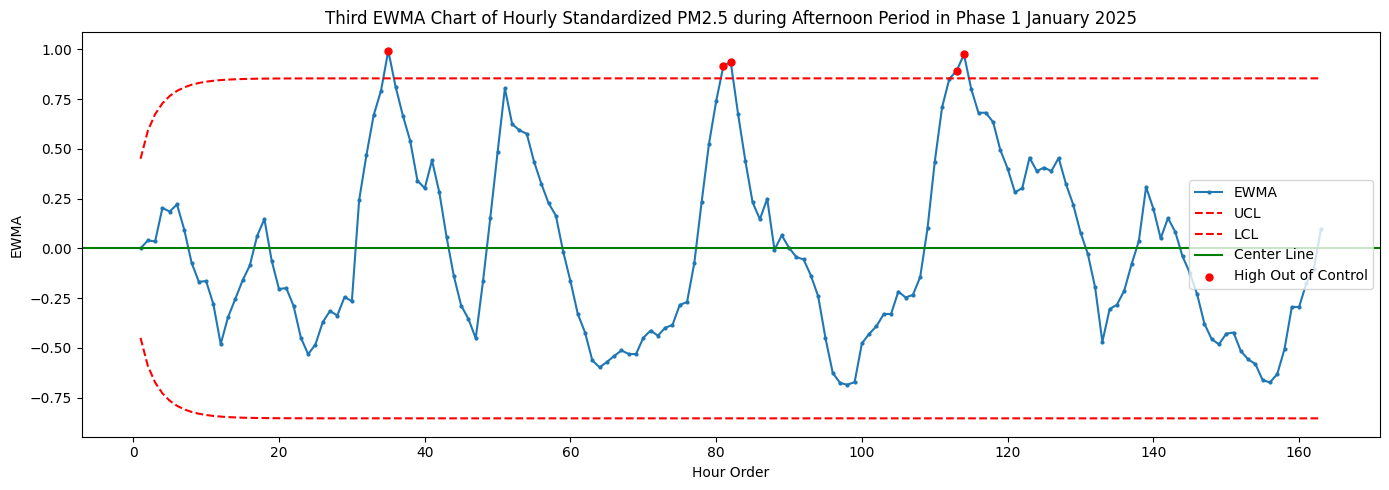

In [14]:
plt.figure(figsize=(14, 5))

x = np.arange(1, len(phase1_ewma_stats_clean2) + 1)

plt.plot(
    x,
    phase1_ewma_stats_clean2["ewma"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="EWMA"
)

plt.plot(
    x,
    phase1_ewma_stats_clean2["ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_ewma_stats_clean2["lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="-",
    label="Center Line"
)

out_high = phase1_ewma_stats_clean2["out_of_control_high"]
out_low = phase1_ewma_stats_clean2["out_of_control_low"]

plt.scatter(
    x[out_high],
    phase1_ewma_stats_clean2.loc[out_high, "ewma"],
    color="red",
    s=25,
    zorder=5,
    label="High Out of Control"
)

plt.title("Third EWMA Chart of Hourly Standardized PM2.5 during Afternoon Period in Phase 1 January 2025")
plt.xlabel("Hour Order")
plt.ylabel("EWMA")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Third cleaning: remove high out-of-control points from the second cleaned Phase I data
phase1_high_out_points_third = phase1_ewma_stats_clean2.loc[
    phase1_ewma_stats_clean2["out_of_control_high"],
    "monitordate"
]

print("Third round removed high out-of-control points:")
print(
    phase1_ewma_stats_clean2.loc[
        phase1_ewma_stats_clean2["out_of_control_high"],
        [
            "monitordate",
            "hour",
            "pm25",
            "z",
            "ewma",
            "ucl"
        ]
    ]
)

phase1_hourly_data_clean3 = phase1_hourly_data_clean2[
    ~phase1_hourly_data_clean2["monitordate"].isin(phase1_high_out_points_third)
].copy()

phase1_hourly_data_clean3 = phase1_hourly_data_clean3.reset_index(drop=True)

print("Second cleaned Phase I size:", phase1_hourly_data_clean2.shape)
print("Third cleaned Phase I size:", phase1_hourly_data_clean3.shape)

Third round removed high out-of-control points:
            monitordate  hour  pm25         z      ewma       ucl
34  2025-01-06 16:00:00    16  21.0  2.134035  0.993131  0.854237
80  2025-01-14 16:00:00    16  20.0  1.928839  0.918273  0.854242
81  2025-01-14 17:00:00    17  16.0  1.032559  0.935416  0.854242
112 2025-01-21 13:00:00    13  15.0  1.112535  0.891599  0.854242
113 2025-01-21 14:00:00    14  19.0  1.449837  0.975335  0.854242
Second cleaned Phase I size: (163, 5)
Third cleaned Phase I size: (158, 5)


In [16]:
phase1_hourly_baseline_clean3 = phase1_hourly_data_clean3.groupby("hour").agg(
    mean_pm25=("pm25", "mean"),
    sd_pm25=("pm25", "std"),
    n=("pm25", "count")
).reset_index()

phase1_hourly_baseline_clean3["sd_pm25"] = (
    phase1_hourly_baseline_clean3["sd_pm25"].replace(0, np.nan)
)

print("\nThird cleaned Phase I hourly baseline:")
print(phase1_hourly_baseline_clean3)


Third cleaned Phase I hourly baseline:
   hour  mean_pm25   sd_pm25   n
0    12   9.000000  4.795832  27
1    13   9.555556  4.693148  27
2    14  10.653846  5.410673  26
3    15  10.888889  6.147753  27
4    16   9.739130  4.025119  23
5    17  10.730769  4.903531  26


In [17]:
phase1_ewma_stats_clean3 = ewma_limits(
    phase1_hourly_data_clean3,
    phase1_hourly_baseline_clean3,
    lam=0.15,
    L=3
)

phase1_ewma_stats_clean3 = phase1_ewma_stats_clean3.reset_index(drop=True)

print("EWMA out-of-control points after third cleaning:")
print(
    phase1_ewma_stats_clean3.loc[
        phase1_ewma_stats_clean3["out_of_control_ewma"],
        [
            "monitordate",
            "hour",
            "pm25",
            "z",
            "ewma",
            "ucl",
            "lcl"
        ]
    ]
)

EWMA out-of-control points after third cleaning:
            monitordate  hour  pm25         z      ewma       ucl       lcl
108 2025-01-21 12:00:00    12  17.0  1.668115  0.951599  0.854242 -0.854242


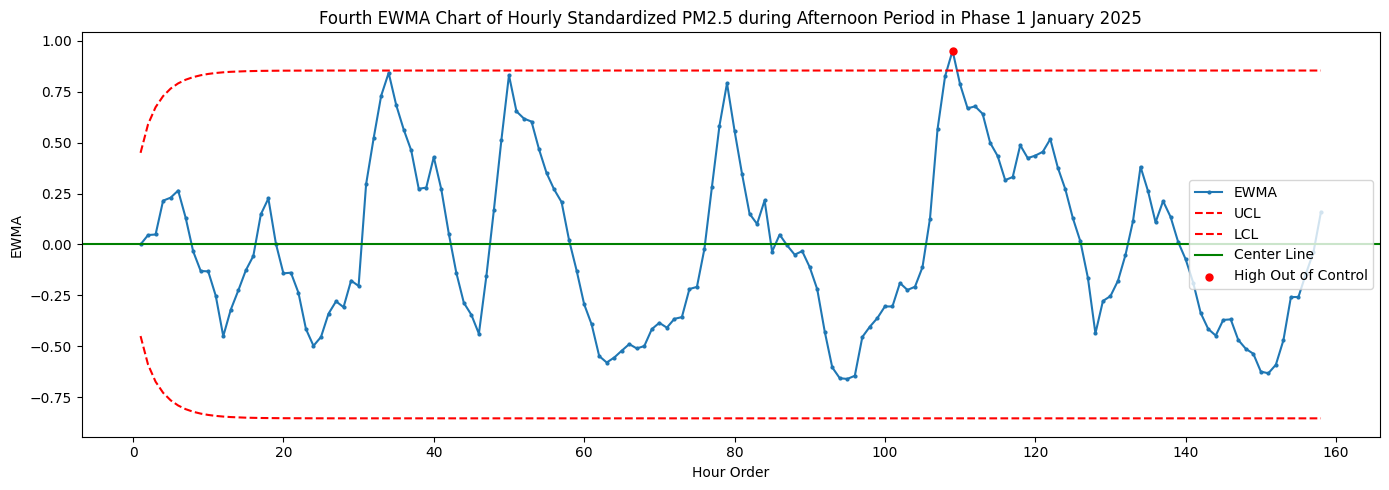

In [18]:
plt.figure(figsize=(14, 5))

x = np.arange(1, len(phase1_ewma_stats_clean3) + 1)

plt.plot(
    x,
    phase1_ewma_stats_clean3["ewma"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="EWMA"
)

plt.plot(
    x,
    phase1_ewma_stats_clean3["ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_ewma_stats_clean3["lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="-",
    label="Center Line"
)

out_high = phase1_ewma_stats_clean3["out_of_control_high"]
out_low = phase1_ewma_stats_clean3["out_of_control_low"]

plt.scatter(
    x[out_high],
    phase1_ewma_stats_clean3.loc[out_high, "ewma"],
    color="red",
    s=25,
    zorder=5,
    label="High Out of Control"
)

plt.title("Fourth EWMA Chart of Hourly Standardized PM2.5 during Afternoon Period in Phase 1 January 2025")
plt.xlabel("Hour Order")
plt.ylabel("EWMA")
plt.legend()

plt.tight_layout()
plt.show()

## Phase 2

In [19]:
## Phase 2 EWMA monitoring

phase2_ewma_stats = ewma_limits(
    phase2_hourly_data,
    phase1_hourly_baseline_clean3,
    lam=0.15,
    L=3
)

phase2_ewma_stats = phase2_ewma_stats.reset_index(drop=True)

phase2_ewma_stats["pm25_exceed_35"] = phase2_ewma_stats["pm25"] > 35

print("Phase II EWMA high out-of-control points:")
print(
    phase2_ewma_stats.loc[
        phase2_ewma_stats["out_of_control_high"],
        [
            "monitordate",
            "hour",
            "pm25",
            "z",
            "ewma",
            "ucl"
        ]
    ]
)

print("\nPhase II summary:")
print("Total observations:", len(phase2_ewma_stats))
print("EWMA high out-of-control count:", phase2_ewma_stats["out_of_control_high"].sum())
print("PM2.5 > 35 count:", phase2_ewma_stats["pm25_exceed_35"].sum())

Phase II EWMA high out-of-control points:
            monitordate  hour  pm25         z      ewma       ucl
29  2026-01-05 17:00:00    17  20.0  1.890318  0.944482  0.854217
30  2026-01-06 12:00:00    12  33.0  5.004346  1.553462  0.854224
31  2026-01-06 13:00:00    13  36.0  5.634692  2.165646  0.854229
32  2026-01-06 14:00:00    14  41.0  5.608573  2.682085  0.854233
33  2026-01-06 15:00:00    15  36.0  4.084600  2.892462  0.854235
..                  ...   ...   ...       ...       ...       ...
112 2026-01-19 16:00:00    16  12.0  0.561690  1.664188  0.854242
113 2026-01-19 17:00:00    17  21.0  2.094252  1.728697  0.854242
114 2026-01-20 12:00:00    12   4.0 -1.042572  1.313007  0.854242
115 2026-01-20 13:00:00    13   6.0 -0.757606  1.002415  0.854242
155 2026-01-26 17:00:00    17  24.0  2.706056  0.887731  0.854242

[83 rows x 6 columns]

Phase II summary:
Total observations: 186
EWMA high out-of-control count: 83
PM2.5 > 35 count: 4


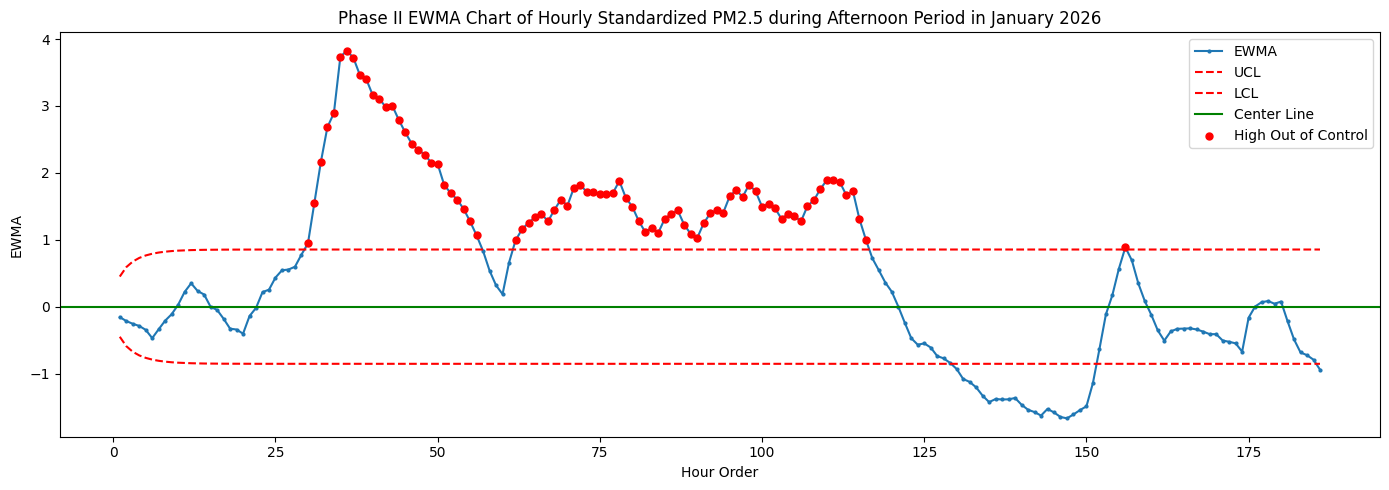

In [20]:
plt.figure(figsize=(14, 5))

x = np.arange(1, len(phase2_ewma_stats) + 1)

plt.plot(
    x,
    phase2_ewma_stats["ewma"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="EWMA"
)

plt.plot(
    x,
    phase2_ewma_stats["ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase2_ewma_stats["lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="-",
    label="Center Line"
)

out_high = phase2_ewma_stats["out_of_control_high"]

plt.scatter(
    x[out_high],
    phase2_ewma_stats.loc[out_high, "ewma"],
    color="red",
    s=25,
    zorder=5,
    label="High Out of Control"
)

plt.title("Phase II EWMA Chart of Hourly Standardized PM2.5 during Afternoon Period in January 2026")
plt.xlabel("Hour Order")
plt.ylabel("EWMA")
plt.legend()

plt.tight_layout()
plt.show()

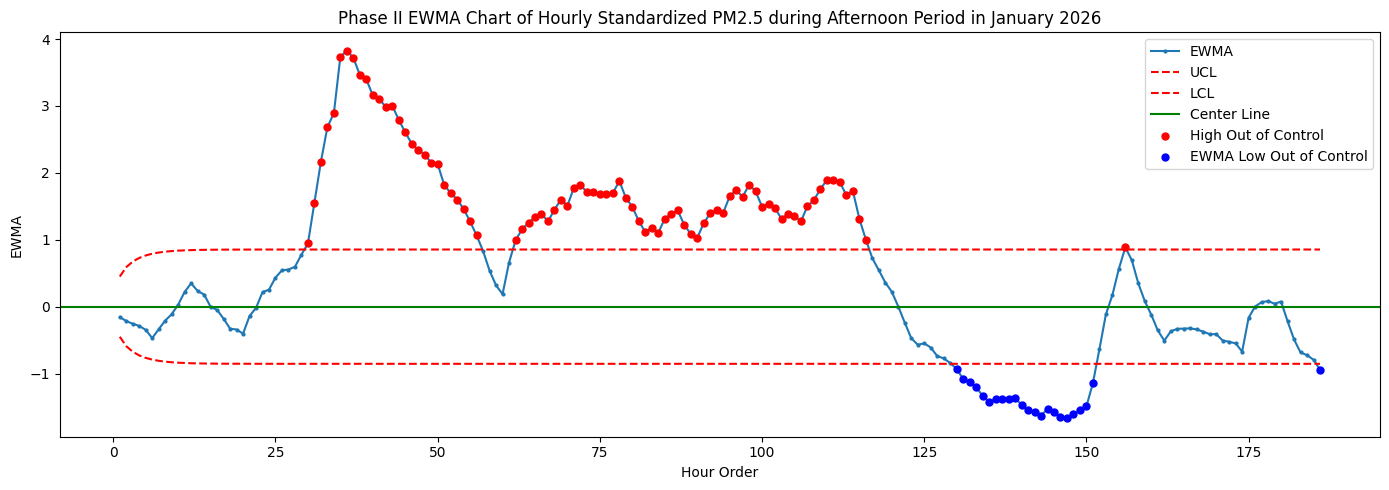

In [21]:
plt.figure(figsize=(14, 5))

x = np.arange(1, len(phase2_ewma_stats) + 1)

plt.plot(
    x,
    phase2_ewma_stats["ewma"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="EWMA"
)

plt.plot(
    x,
    phase2_ewma_stats["ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase2_ewma_stats["lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="-",
    label="Center Line"
)

out_high = phase2_ewma_stats["out_of_control_high"]

plt.scatter(
    x[out_high],
    phase2_ewma_stats.loc[out_high, "ewma"],
    color="red",
    s=25,
    zorder=5,
    label="High Out of Control"
)
out_low = phase2_ewma_stats["out_of_control_low"]

plt.scatter(
    x[out_low],
    phase2_ewma_stats.loc[out_low, "ewma"],
    color="blue",
    s=25,
    zorder=5,
    label="EWMA Low Out of Control"
)

plt.title("Phase II EWMA Chart of Hourly Standardized PM2.5 during Afternoon Period in January 2026")
plt.xlabel("Hour Order")
plt.ylabel("EWMA")
plt.legend()

plt.tight_layout()
plt.show()

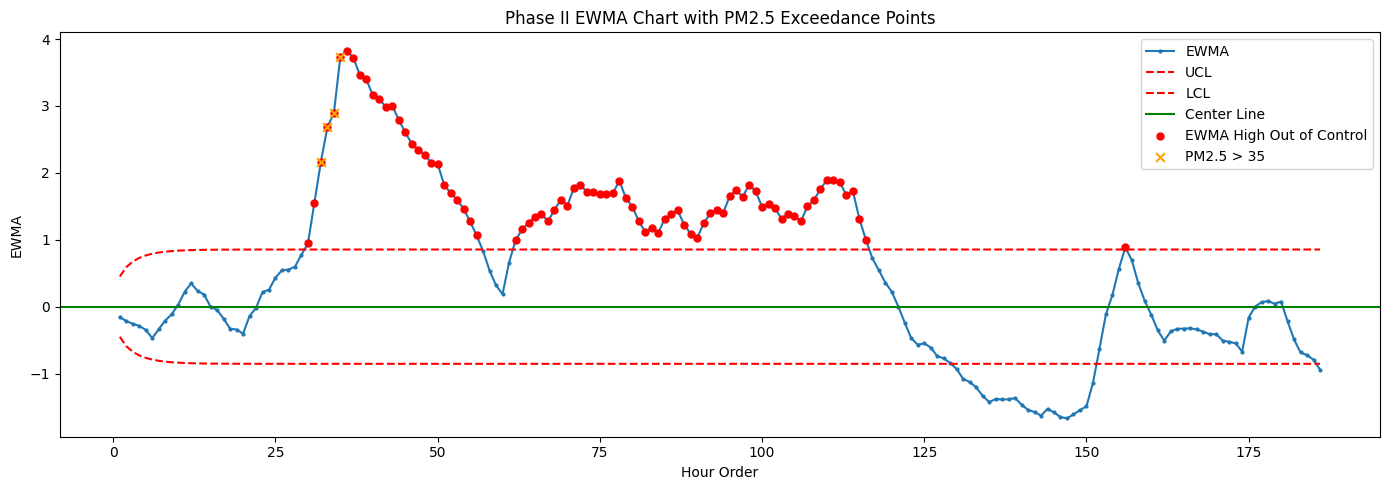

In [22]:
plt.figure(figsize=(14, 5))

x = np.arange(1, len(phase2_ewma_stats) + 1)

plt.plot(
    x,
    phase2_ewma_stats["ewma"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="EWMA"
)

plt.plot(
    x,
    phase2_ewma_stats["ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase2_ewma_stats["lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="-",
    label="Center Line"
)

out_high = phase2_ewma_stats["out_of_control_high"]
exceed_35 = phase2_ewma_stats["pm25_exceed_35"]

plt.scatter(
    x[out_high],
    phase2_ewma_stats.loc[out_high, "ewma"],
    color="red",
    s=25,
    zorder=5,
    label="EWMA High Out of Control"
)

plt.scatter(
    x[exceed_35],
    phase2_ewma_stats.loc[exceed_35, "ewma"],
    color="orange",
    s=40,
    marker="x",
    zorder=6,
    label="PM2.5 > 35"
)

plt.title("Phase II EWMA Chart with PM2.5 Exceedance Points")
plt.xlabel("Hour Order")
plt.ylabel("EWMA")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
# High EWMA signal periods
phase2_ewma_stats["new_high_signal"] = (
    phase2_ewma_stats["out_of_control_high"] &
    ~phase2_ewma_stats["out_of_control_high"].shift(fill_value=False)
)

phase2_ewma_stats["high_signal_group"] = (
    phase2_ewma_stats["new_high_signal"].cumsum()
)

phase2_high_ewma_periods = (
    phase2_ewma_stats.loc[phase2_ewma_stats["out_of_control_high"]]
    .groupby("high_signal_group")
    .agg(
        start_time=("monitordate", "first"),
        end_time=("monitordate", "last"),
        start_date=("date", "first"),
        end_date=("date", "last"),
        start_hour=("hour", "first"),
        end_hour=("hour", "last"),
        signal_count=("monitordate", "count"),
        max_pm25=("pm25", "max"),
        max_z=("z", "max"),
        max_ewma=("ewma", "max")
    )
    .reset_index(drop=True)
)

print("\nPhase II high EWMA signal periods:")
print(phase2_high_ewma_periods)


# Low EWMA signal periods
phase2_ewma_stats["new_low_signal"] = (
    phase2_ewma_stats["out_of_control_low"] &
    ~phase2_ewma_stats["out_of_control_low"].shift(fill_value=False)
)

phase2_ewma_stats["low_signal_group"] = (
    phase2_ewma_stats["new_low_signal"].cumsum()
)

phase2_low_ewma_periods = (
    phase2_ewma_stats.loc[phase2_ewma_stats["out_of_control_low"]]
    .groupby("low_signal_group")
    .agg(
        start_time=("monitordate", "first"),
        end_time=("monitordate", "last"),
        start_date=("date", "first"),
        end_date=("date", "last"),
        start_hour=("hour", "first"),
        end_hour=("hour", "last"),
        signal_count=("monitordate", "count"),
        min_pm25=("pm25", "min"),
        min_z=("z", "min"),
        min_ewma=("ewma", "min")
    )
    .reset_index(drop=True)
)

print("\nPhase II low EWMA signal periods:")
print(phase2_low_ewma_periods)


Phase II high EWMA signal periods:
           start_time            end_time  start_date    end_date  start_hour  \
0 2026-01-05 17:00:00 2026-01-10 13:00:00  2026-01-05  2026-01-10          17   
1 2026-01-11 13:00:00 2026-01-20 13:00:00  2026-01-11  2026-01-20          13   
2 2026-01-26 17:00:00 2026-01-26 17:00:00  2026-01-26  2026-01-26          17   

   end_hour  signal_count  max_pm25     max_z  max_ewma  
0        13            27      44.0  8.511766  3.825684  
1        13            55      25.0  3.294529  1.896522  
2        17             1      24.0  2.706056  0.887731  

Phase II low EWMA signal periods:
           start_time            end_time  start_date    end_date  start_hour  \
0 2026-01-22 15:00:00 2026-01-26 12:00:00  2026-01-22  2026-01-26          15   
1 2026-01-31 17:00:00 2026-01-31 17:00:00  2026-01-31  2026-01-31          17   

   end_hour  signal_count  min_pm25     min_z  min_ewma  
0        12            22       0.0 -2.036065 -1.669167  
1        17 